In [1]:
import numpy as np
from pathlib import Path

In [11]:
BASE_DIR = Path().resolve()
path = BASE_DIR / "data" / "preprocessed_all_debug.npy"
path2 = BASE_DIR / "data" / "preprocessed_all.npy"
path_masked = BASE_DIR / "data" / "preprocessed_all_masks_debug.npy"
path_masked2 = BASE_DIR / "data" / "preprocessed_all_masks.npy"

In [12]:
mm = np.memmap(path_masked, mode="r", shape=(10, 155, 1, 128, 128), dtype=np.float32)

In [13]:
mm.shape

(10, 155, 1, 128, 128)

In [14]:
mm[1][2].shape

(1, 128, 128)

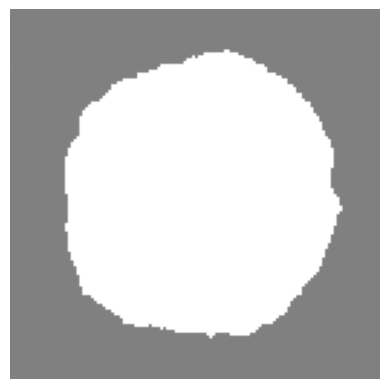

In [15]:
x = mm[0][80].squeeze(0)
x_vis = (x + 1) / 2

plt.imshow(x_vis, cmap='gray', vmin=0.0, vmax=1.0)
plt.axis('off')
plt.show()

In [3]:
mm2 = np.memmap(path2, mode="r", shape=(1251, 155, 1, 128, 128), dtype=np.float32)

In [4]:
mm2.shape

(1251, 155, 1, 128, 128)

In [5]:
mm2.size

3176939520

In [6]:
mm2.itemsize

4

In [3]:
import matplotlib.pyplot as plt

In [4]:
x = mm2[0][80].squeeze(0)
x_vis = (x + 1) / 2

plt.imshow(x_vis, cmap='gray', vmin=0.0, vmax=1.0)
plt.axis('off')
plt.show()

NameError: name 'mm2' is not defined

In [25]:
from experiments.ddpm_25d.mm_dataset import MemmapDataset

In [13]:
dataset = MemmapDataset(path2)

self.data.shape=(1251, 155, 1, 128, 128)


In [53]:
data = np.memmap(path2, mode='r', shape=(1251, 155, 1, 128, 128), dtype=np.float32)

In [55]:
data.shape[1]

155

In [32]:
import torch
import time

BASE_DIR = Path().resolve()
BRATS_ROOT = Path(BASE_DIR / "data" / "brats-2021").expanduser()
PREPROCESSED_ROOT = Path(BASE_DIR / "data" / "preprocessed").expanduser()

BATCH_SIZE = 128
REPETITIONS = 5
ITERATIONS = 20

workers = 0

In [33]:
for _ in range(REPETITIONS):
    dataloader = torch.utils.data.DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        num_workers=workers,
        shuffle=True,
        persistent_workers=False,
        pin_memory=True,
    )
    dataiter = iter(dataloader)
    t0 = time.time()
    batch = next(dataiter)
    t1 = time.time()
    print("First batch load:", t1 - t0, "s")

    for i, batch in enumerate(dataloader):
        if i == ITERATIONS:
            break
    t2 = time.time()
    print("workers:", workers, f", {ITERATIONS} batches:", t2 - t1, "s → per batch ~", (t2 - t1) / ITERATIONS, "s")

<string>:11: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:203.)


First batch load: 0.4161217212677002 s
workers: 0 , 20 batches: 6.375321865081787 s → per batch ~ 0.31876609325408933 s
First batch load: 0.2808873653411865 s
workers: 0 , 20 batches: 6.411114692687988 s → per batch ~ 0.3205557346343994 s
First batch load: 0.3753392696380615 s
workers: 0 , 20 batches: 6.193764686584473 s → per batch ~ 0.30968823432922366 s
First batch load: 0.2863423824310303 s
workers: 0 , 20 batches: 5.936670541763306 s → per batch ~ 0.2968335270881653 s
First batch load: 0.2510662078857422 s
workers: 0 , 20 batches: 5.652616500854492 s → per batch ~ 0.28263082504272463 s


In [23]:
%load_ext autoreload
%autoreload 2

In [1]:
from experiments.ddpm_25d.training import main

ModuleNotFoundError: No module named 'mlflow'

In [2]:
from experiments.ddpm_25d.mm_dataset import get_debug_dataset
ds = get_debug_dataset()

self.data.shape=(10, 155, 1, 128, 128)


In [3]:
ds

In [5]:
next(iter(ds))

/hkfs/home/haicore/scc/ml8238/mri-diffusion/experiments/ddpm_25d/mm_dataset.py:29: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:203.)
  "context": torch.from_numpy(self.data[vol_idx, slice_idx]),        # slice k


{'context': tensor([[[-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          ...,
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.]]]),
 'neighbor': tensor([[[-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          ...,
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.]]]),
 'direction': -1,
 'slice_pos': -0.006451612903225823}

In [1]:
from experiments.ddpm_25d.mm_dataset_masked import get_debug_dataset
ds = get_debug_dataset()

self.data.shape=(10, 155, 1, 128, 128)


In [2]:
ds[0]

/hkfs/home/haicore/scc/ml8238/mri-diffusion/experiments/ddpm_25d/mm_dataset_masked.py:31: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:203.)
  "context": torch.from_numpy(self.data[vol_idx, slice_idx]),        # slice k


{'context': tensor([[[-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          ...,
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.]]]),
 'neighbor_mask': tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]]),
 'neighbor': tensor([[[-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          ...,
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.]]]),
 'direction': -1,
 'slice_pos': -0.006451612903225823}

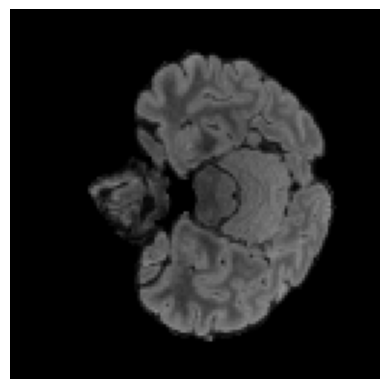

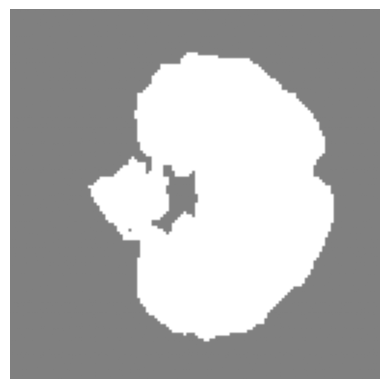

In [16]:
s = ds[100]

x = s["neighbor"].squeeze(0)
x_vis = (x + 1) / 2

plt.imshow(x_vis, cmap='gray', vmin=0.0, vmax=1.0)
plt.axis('off')
plt.show()

x = s["neighbor_mask"].squeeze(0)
x_vis = (x + 1) / 2

plt.imshow(x_vis, cmap='gray', vmin=0.0, vmax=1.0)
plt.axis('off')
plt.show()

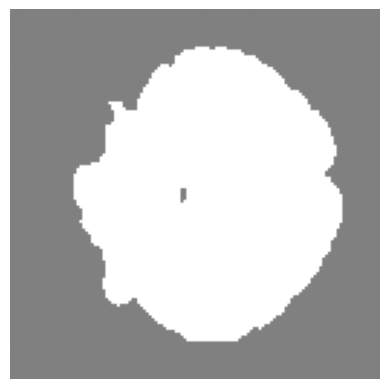

In [13]:
x = ds[120]["neighbor_mask"].squeeze(0)
x_vis = (x + 1) / 2

plt.imshow(x_vis, cmap='gray', vmin=0.0, vmax=1.0)
plt.axis('off')
plt.show()